<a href="https://colab.research.google.com/github/NATHAN-70/AI-ML/blob/main/k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/personality_datasert (1).csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [ ]:
df.isnull().sum()

,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,0
1,9.0,1,0.0,0.0,1,0.0,3.0,1
2,9.0,1,1.0,2.0,1,5.0,2.0,1
3,0.0,0,6.0,7.0,0,14.0,8.0,0
4,3.0,0,9.0,4.0,0,8.0,5.0,0
...,...,...,...,...,...,...,...,...
2895,3.0,0,7.0,6.0,0,6.0,6.0,0
2896,3.0,0,8.0,3.0,0,14.0,9.0,0
2897,4.0,1,1.0,1.0,1,4.0,0.0,1
2898,11.0,1,1.0,3.0,1,2.0,0.0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Time_spent_Alone']=sc.fit_transform(df[['Time_spent_Alone']])
df['Social_event_attendance']=sc.fit_transform(df[['Social_event_attendance']])
df['Going_outside']=sc.fit_transform(df[['Going_outside']])
df['Friends_circle_size']=sc.fit_transform(df[['Friends_circle_size']])
df['Post_frequency']=sc.fit_transform(df[['Post_frequency']])
df


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,-0.147014,0,0.012759,1.350613,0,1.590680,0.496104,0
1,1.306226,1,-1.379944,-1.350613,1,-1.481437,-0.195199,1
2,1.306226,1,-1.031768,-0.450204,1,-0.299853,-0.540850,1
3,-1.309607,0,0.709111,1.800817,0,1.826996,1.533059,0
4,-0.437663,0,1.753638,0.450204,0,0.409096,0.496104,0
...,...,...,...,...,...,...,...,...
2895,-0.437663,0,1.057286,1.350613,0,-0.063537,0.841756,0
2896,-0.437663,0,1.405462,0.000000,0,1.826996,1.878710,0
2897,-0.147014,1,-1.031768,-0.900408,1,-0.536170,-1.232153,1
2898,1.887522,1,-1.031768,0.000000,1,-1.008803,-1.232153,1


In [ ]:
x=df.drop('Personality',axis=1)

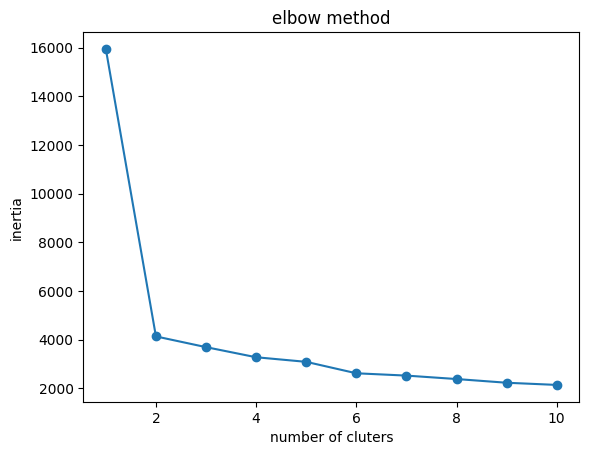

In [ ]:
from sklearn.cluster import KMeans
intertia=[]
for k in range(1,11):
     kmeans= KMeans(n_clusters=k,random_state=42)
     kmeans.fit(x)
     intertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11),intertia,marker='o')
plt.title('elbow method')
plt.xlabel('number of cluters')
plt.ylabel('inertia')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=2,random_state=42)
kmeans.fit(x)

KMeans(n_clusters=2, random_state=42)

In [ ]:
cluster=kmeans.predict(x)

In [ ]:
df['cluster']=cluster

In [ ]:
df['cluster']

,cluster
0,0
1,1
2,1
3,0
4,0
...,...
2895,0
2896,0
2897,1
2898,1


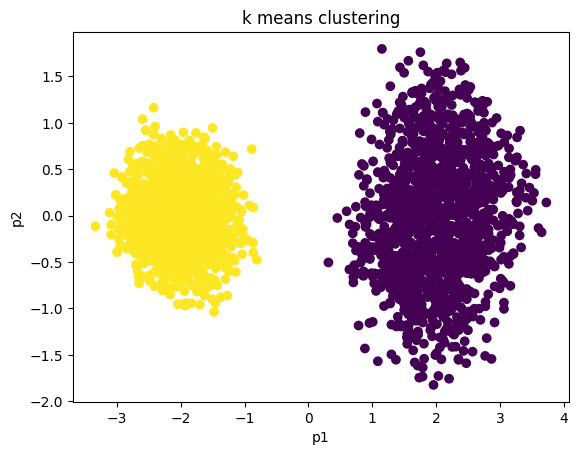

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x)

plt.figure()
plt.scatter(x_pca[:,0],x_pca[:,1],c=cluster)
plt.title('k means clustering')
plt.xlabel("p1")
plt.ylabel('p2')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x,cluster)
print(score)

0.6253579158512802
